# Experiment H: does the encoder representation actually degrade at 25 s?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AgrfhyL/audio_model_initial_testing/blob/main/Colab_EncoderSimilarity.ipynb)

Experiment C asks whether the positional penalty lives in the encoder or the decoder and answers
with teacher-forced NLL. That is the right axis for a behavioural claim, but every number it
produces has passed through decoder weights — it reads the representation *through* the thing it is
trying to exonerate.

This notebook reads the encoder directly. **No decoding, no tokenizer, no references, no WER.** One
encoder forward pass per (clip, condition), then a comparison of the frames that carry the
utterance. It is the only experiment here that touches licensed audio and derives nothing whatever
from the licensed *text*.

The comparison is clean because of an invariant this repo already established: offsets 5 s and 25 s
produce **bit-identical mel frames**. The conv stack sees a pure translation of the same input. So
any difference at matched content frames is produced by the encoder itself — the positional
embedding and the self-attention over it — and by nothing else.

### What each account predicts

| | content-frame similarity, 25 s vs 5 s | across scale |
|---|---|---|
| **Encoder account** | degraded: the representation of the audio is genuinely worse at 25 s | damage shrinks in step with the WER penalty (14.4x -> 2.2x) |
| **Decoder account** | intact up to the positional component | damage flat and near zero at every size |

As in Experiment C the discriminator is the **shape across scale**, so this runs the same five-model
ladder on the same 1000 clips, and rows join to `expc_per_utterance.csv` by `path`.

## The three metrics, and one trap

Let $A \in \mathbb{R}^{L \times d}$ be the encoder output rows carrying the utterance at 5 s, and
$B$ the matching rows at 25 s. $L = \lceil \text{duration} \times 50 \rceil$, since 1500 encoder
frames over 30 s is **50 frames per second**.

1. **Mean per-frame cosine** — $\frac{1}{L}\sum_i \cos(A_i, B_i)$. Compares vectors directly.
2. **Linear CKA** — invariant to rotation, translation and isotropic scaling, so it asks whether the
   same *geometry* is present rather than whether the coordinates match.
3. **Relative $L_2$** — $\lVert B - A\rVert_F / \lVert A \rVert_F$. A scale-sensitive magnitude.

**The trap: raw cosine is dominated by the positional component and will mislead you.** The encoder
adds `positional_embedding` before the transformer blocks, so frames at different positions differ
by construction whether or not the acoustic content survives. The control that makes this legible is
a **position floor**: two bands that are silent under *every* condition, taken from a single forward
pass and displaced by exactly 1000 frames — the same 20 s that separates 5 s from 25 s. Identical
input, matched displacement, no content at all.

A local `base` preview (16 clips, fp32) sizes all three quantities:

| comparison | mean cosine | linear CKA |
|---|---|---|
| content frames, 25 s vs 5 s (**C1**) | 0.572 | 0.991 |
| position floor — silence, identical input, 20 s apart | 0.302 | 0.403 |
| content frames, PE rolled -20 s (**C2**) | 0.9996 | 0.9999 |

The content cosine of 0.572 sits nearer the positional floor than it does to 1.0, so reporting it as
"43% degraded" would be nonsense. CKA over the same frames is 0.991 — and crucially CKA is *not*
trivially high, because the same measure over the floor returns 0.403. It separates "the same
content at a different position" from "no shared content", which is precisely the distinction the
two accounts disagree about.

The `C2` arm is the decisive one: rolling the positional embedding by -20 s gives the frames at 25 s
the embedding of the frames at 5 s. If the representation is intact modulo position, C2 collapses
onto C0. In this preview it does, to four decimal places.

## Conditions

Identical to Experiment C, deliberately, so the two sets of rows join by `(model, path)`:

| | placement | positional embedding | compared against |
|---|---|---|---|
| **C0** | 5 s | unmodified | — (the reference) |
| **C1** | 25 s | unmodified | C0 |
| **C2** | 25 s | rolled -20 s | C0 |

C2 is not a perfect reconstruction of C0 and is not meant to be. A cyclic roll rotates the *whole*
window's positional labelling, so the silence surrounding the utterance is labelled differently even
though the utterance itself is labelled 5 s. Residual difference under C2 is that contextual effect,
which is exactly why it is reported rather than assumed away.

## 1. Environment

GPU, fp16 by the same route as every other Colab sweep here, and a pinned batch size.

In [1]:
!pip -q install openai-whisper soundfile

import subprocess, torch
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                      "--format=csv,noheader"], capture_output=True, text=True).stdout.strip())
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
assert torch.cuda.is_available(), "Runtime > Change runtime type > GPU"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 39.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Tesla T4, 15360 MiB, 580.82.07
torch 2.11.0+cu128 | cuda True


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Provenance

Package versions, SHA-256 of the `whisper` source that defines the code path actually run, each
checkpoint verified against the digest embedded in its download URL, device and precision.

**Licensing.** TIMIT is LDC93S1 — licensed, not redistributable, and saving a Colab notebook back
to GitHub commits its outputs. This notebook never loads a transcript at all: it needs no
references, produces no hypotheses, and its single results file is numbers and paths by
construction. There is no Drive-only companion because there is nothing to keep out of git.

In [3]:
import hashlib, json, os, platform

DRIVE_ROOT = "/content/drive/MyDrive/NAACL"
SAFE_CSV   = os.path.join(DRIVE_ROOT, "encsim_per_utterance.csv")   # numbers only, git-safe
LAYER_CSV  = os.path.join(DRIVE_ROOT, "encsim_per_layer.csv")       # numbers only, git-safe
PROV_JSON  = os.path.join(DRIVE_ROOT, "encsim_provenance.json")
LOCAL_AUDIO = "/content/corpus"
REPO = "AgrfhyL/audio_model_initial_testing"


def sha256_file(path, buf=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()


def sha256_bytes(b):
    return hashlib.sha256(b).hexdigest()


import numpy, soundfile, whisper

_wdir = os.path.dirname(whisper.__file__)
CODE_DIGESTS = {f: sha256_file(os.path.join(_wdir, f))[:16]
                for f in ("audio.py", "model.py")}
try:
    import urllib.request
    with urllib.request.urlopen(
            f"https://api.github.com/repos/{REPO}/commits/main", timeout=10) as r:
        REPO_COMMIT = json.load(r)["sha"]
except Exception as e:
    REPO_COMMIT = f"unavailable ({type(e).__name__})"

PROVENANCE = {
    "experiment": "Experiment H -- direct encoder-side similarity, no decoding",
    "question": "is the acoustic representation at 25 s degraded, or intact but relabelled?",
    "conditions": "C0 5s | C1 25s | C2 25s PE-20s; all compared to C0 at matched content frames",
    "metrics": {
        "cos": "mean per-frame cosine over content frames",
        "cka": "linear CKA over content frames (rotation/scale invariant)",
        "rel_l2": "||B - A||_F / ||A||_F over content frames",
        "silence_control": "same metrics on a fixed window that is silent in every condition",
    },
    "packages": {
        "python": platform.python_version(), "openai-whisper": whisper.__version__,
        "torch": torch.__version__, "numpy": numpy.__version__,
        "soundfile": soundfile.__version__,
        "cuda": torch.version.cuda, "cudnn": torch.backends.cudnn.version(),
    },
    "code_version": {"whisper_source_sha256_16": CODE_DIGESTS, "repo": REPO,
                     "repo_commit": REPO_COMMIT},
    "device": {"name": torch.cuda.get_device_name(0),
               "capability": ".".join(map(str, torch.cuda.get_device_capability(0))),
               "precision": "fp32 weights, fp16 mel; encoder returns fp16, metrics in fp32"},
}
print(json.dumps(PROVENANCE, indent=1))

{
 "experiment": "Experiment H -- direct encoder-side similarity, no decoding",
 "question": "is the acoustic representation at 25 s degraded, or intact but relabelled?",
 "conditions": "C0 5s | C1 25s | C2 25s PE-20s; all compared to C0 at matched content frames",
 "metrics": {
  "cos": "mean per-frame cosine over content frames",
  "cka": "linear CKA over content frames (rotation/scale invariant)",
  "rel_l2": "||B - A||_F / ||A||_F over content frames",
  "silence_control": "same metrics on a fixed window that is silent in every condition"
 },
 "packages": {
  "python": "3.13.15",
  "openai-whisper": "20250625",
  "torch": "2.11.0+cu128",
  "numpy": "2.1.3",
  "soundfile": "0.14.0",
  "cuda": "12.8",
  "cudnn": 91900
 },
 "code_version": {
  "whisper_source_sha256_16": {
   "audio.py": "36ed287b2de3eaf4",
   "model.py": "473491a97554ad1d"
  },
  "repo": "AgrfhyL/audio_model_initial_testing",
  "repo_commit": "2ebda0093a19282f5d1ad1ea0fbcb4831192dbb1"
 },
 "device": {
  "name": "Tesl

## 3. Corpus: the same 1000 clips

The full seed-0 draw from `corpus_digests.json`, so rows join to the earlier sweeps by `path`. Each
clip is copied to local disk (Drive's FUSE mount is far too slow to read repeatedly) and checked
against its frozen `sha256_audio`, a digest over the decoded float32 samples.

Note what is *absent*: no `.TXT` is ever opened. This experiment has no reference text and needs
none.

In [4]:
import collections, glob, shutil, time
import numpy as np
import soundfile as sf

cands = [d for d in glob.glob(os.path.join(DRIVE_ROOT, "timit", "**", "TEST"), recursive=True)
         if os.path.isdir(os.path.join(d, "DR1"))]
assert cands, f"no TIMIT TEST/DR1 found under {DRIVE_ROOT}/timit"
TIMIT_TEST = sorted(cands, key=len)[0]

if not os.path.exists("corpus_digests.json"):
    !wget -q https://raw.githubusercontent.com/AgrfhyL/audio_model_initial_testing/main/corpus_digests.json
DIG = json.load(open("corpus_digests.json"))


def sha256_audio(a):
    return hashlib.sha256(np.ascontiguousarray(a, dtype=np.float32).tobytes()).hexdigest()


FILES, AUDIO, bad = [], {}, []
t0 = time.time()
for r in DIG["files"]:
    src = os.path.join(TIMIT_TEST, r["path"]); dst = os.path.join(LOCAL_AUDIO, r["path"])
    if not os.path.exists(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True); shutil.copy2(src, dst)
    a, sr = sf.read(dst, dtype="float32")
    if sr != DIG["sample_rate"] or len(a) != r["samples"] or sha256_audio(a) != r["sha256_audio"]:
        bad.append(r["path"]); continue
    AUDIO[r["path"]] = a; FILES.append(r)

assert not bad, f"{len(bad)} clips fail their frozen digest, e.g. {bad[:3]}"
assert len(FILES) == 1000
spk = collections.Counter(r["speaker"] for r in FILES)
print(f"verified {len(FILES)} clips in {time.time()-t0:.0f}s | {len(spk)} speakers "
      f"({min(spk.values())}-{max(spk.values())} each) | "
      f"{sum(r['sec'] for r in FILES)/60:.1f} min audio | no transcripts read")

verified 1000 clips in 721s | 168 speakers (5-6 each) | 49.3 min audio | no transcripts read


## 4. Conditions, the positional-embedding control, and the mel gate

`rolled_pe` is the same context manager Experiments B and C use: a **cyclic roll**, never rebuilt
sinusoids. Extrapolating to shifted positions gives leading-silence frames negative positions the
model never saw in training and is catastrophic (measured elsewhere in this repo: corpus WER
0.0586 -> 6.4163). A roll keeps every row a genuine training-time position. `load_model` caches, so
restoration is asserted rather than assumed.

The mel gate is the control the whole comparison rests on: 5 s and 25 s must be exact integer-frame
shifts of each other, checked at both filterbank sizes since `large-v3` uses 128 mel bins where the
smaller models use 80.

**Precision.** The model is loaded fp32 and the *mel* is cast to fp16 — which is what `decode()`
does internally, so these encoder outputs are the ones the earlier sweeps actually decoded from.
Whisper's custom `Conv1d`/`Linear` cast weights to the input dtype (`model.py`), which is why this
works without ever calling `model.half()`. Metrics are computed in fp32.

`BATCH` is **pinned**, not discovered: fp16 kernel selection varies with batch shape at the ~1e-3
level, and that only cancels out of a comparison if every condition for a clip is encoded at the
same batch index and size.

In [5]:
import contextlib, gc
from whisper.audio import log_mel_spectrogram, N_SAMPLES, SAMPLE_RATE, HOP_LENGTH

MODELS = ["tiny", "base", "small", "medium", "large-v3"]
BATCH  = 8                      # divides 1000 exactly; pinned, see above
PE_FPS = 50                     # 1500 encoder frames / 30 s
N_CTX  = 1500                   # n_audio_ctx, identical across all Whisper sizes

# name, offset_s, pe_shift_s
CONDITIONS = [("C0",  5, None),
              ("C1", 25, None),
              ("C2", 25,  -20)]
OFFSETS_S  = sorted({c[1] for c in CONDITIONS})

# Two bands that are silent under every condition (content lives in 250-499 and 1250-1499).
# SIL_A vs SIL_B inside one pass is the position floor; SIL_A across passes is contextual leakage.
SIL_A = slice(0, 200)
SIL_B = slice(1000, 1200)      # exactly 1000 frames = 20 s after SIL_A, matching 5 s -> 25 s


@contextlib.contextmanager
def rolled_pe(model, seconds):
    """Cyclically roll the encoder positional embedding by `seconds`, restoring on exit."""
    pe = model.encoder.positional_embedding
    saved = pe.detach().clone()
    try:
        if seconds:
            pe.copy_(torch.roll(saved, shifts=int(-seconds * PE_FPS), dims=0))
        yield
    finally:
        pe.copy_(saved)
        assert torch.equal(pe, saved), "positional embedding was not restored"


def place(audio, off_s):
    buf = np.zeros(N_SAMPLES, dtype=np.float32)
    o = off_s * SAMPLE_RATE
    buf[o:o + len(audio)] = audio
    return buf


def mel_of(audio, off_s, n_mels):
    return log_mel_spectrogram(torch.from_numpy(place(audio, off_s)), n_mels)


def content_slice(off_s, sec):
    a = off_s * PE_FPS
    return slice(a, a + int(np.ceil(sec * PE_FPS)))


for s in OFFSETS_S:
    assert (s * SAMPLE_RATE) % HOP_LENGTH == 0
for r in FILES:
    for s in OFFSETS_S:
        assert s * SAMPLE_RATE + r["samples"] <= N_SAMPLES, (r["path"], s)
    assert content_slice(25, r["sec"]).stop <= N_CTX, r["path"]
assert len(FILES) % BATCH == 0, f"{len(FILES)} not divisible by BATCH={BATCH}"

# --- mel gate: 5 s vs 25 s bit-identical, at both filterbank sizes ---
import random as _random
FPS, NF = SAMPLE_RATE // HOP_LENGTH, N_SAMPLES // HOP_LENGTH
gate = {}
for n_mels in (80, 128):
    worst = 0.0
    for r in _random.Random(7).sample(FILES, min(40, len(FILES))):
        a = AUDIO[r["path"]]; nf = int(np.ceil(len(a) / HOP_LENGTH)) + 2
        m5, m25 = mel_of(a, 5, n_mels).numpy(), mel_of(a, 25, n_mels).numpy()
        n = min(nf, NF - 25 * FPS)
        worst = max(worst, float(np.abs(m25[:, 25*FPS:25*FPS+n] - m5[:, 5*FPS:5*FPS+n]).max()))
    gate[n_mels] = worst
    assert worst == 0.0, f"mel gate FAILED at n_mels={n_mels}: {worst:.3e}"

corpus_digest = sha256_bytes("\n".join(
    f"{r['path']}\t{r['sha256_audio']}" for r in FILES).encode())
PROVENANCE["corpus"] = {
    "source": "TIMIT (LDC93S1) TEST -- licensed, not redistributable",
    "spec_sha256": sha256_file("corpus_digests.json"), "n_clips": len(FILES),
    "n_speakers": len({r["speaker"] for r in FILES}),
    "corpus_digest_sha256": corpus_digest, "references_used": False,
}
PROVENANCE["encoding"] = {"batch": BATCH, "conditions": CONDITIONS,
                          "pe_fps": PE_FPS, "silence_bands_frames": [[SIL_A.start, SIL_A.stop], [SIL_B.start, SIL_B.stop]]}
PROVENANCE["mel_gate"] = {"offsets_compared": OFFSETS_S, "max_abs_dev_by_n_mels": gate}
print("mel gate: 5 s vs 25 s bit-identical at " +
      ", ".join(f"n_mels={k} (|dev| {v:.1e})" for k, v in gate.items()))
print("corpus digest", corpus_digest)

mel gate: 5 s vs 25 s bit-identical at n_mels=80 (|dev| 0.0e+00), n_mels=128 (|dev| 0.0e+00)
corpus digest e96c305897ff0c609b59df8a9ae3d9674a88e43da02012208f8d4114f8c026ed


## 5. The metrics

Three functions, all operating on an $L \times d$ block of encoder rows. Linear CKA is the standard
form: $\lVert B^\top A\rVert_F^2 / (\lVert A^\top A\rVert_F \lVert B^\top B\rVert_F)$ on
column-centred inputs.

In [6]:
def cos_rows(A, B):
    n = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    return (A * B).sum(1) / np.maximum(n, 1e-12)


def linear_cka(A, B):
    A = A - A.mean(0, keepdims=True)
    B = B - B.mean(0, keepdims=True)
    denom = np.linalg.norm(A.T @ A, "fro") * np.linalg.norm(B.T @ B, "fro")
    if denom == 0:
        return float("nan")
    return float(np.linalg.norm(B.T @ A, "fro") ** 2 / denom)


def rel_l2(A, B):
    d = np.linalg.norm(A)
    return float(np.linalg.norm(B - A) / d) if d > 0 else float("nan")


def compare(A, B):
    return {"cos": float(cos_rows(A, B).mean()), "cka": linear_cka(A, B), "rel_l2": rel_l2(A, B)}


def encode_batch(model, auds, off_s, shift, n_mels):
    """One encoder pass for a batch placed at `off_s`, optionally with the PE rolled.

    The model is fp32 and only the mel is cast, which is what `decode()` does internally --
    whisper's custom Conv1d/Linear cast weights to the input dtype, so the encoder runs and
    returns fp16 without `model.half()` ever being called. Metrics are taken in fp32.
    """
    mel = torch.stack([mel_of(a, off_s, n_mels) for a in auds])
    with torch.no_grad(), rolled_pe(model, shift):
        return model.encoder(mel.half().cuda()).float().cpu().numpy()

### Self-checks

Four properties the sweep silently depends on, asserted before 15 000 encoder passes are spent on
them: the metrics are self-consistent, a zero roll is a no-op, the positional embedding really is
restored, and encoding is reproducible at the pinned batch shape.

In [7]:
_m = whisper.load_model("tiny", device="cuda")
_a = [AUDIO[r["path"]] for r in FILES[:BATCH]]
_nm = _m.dims.n_mels


# 1. metric self-consistency
_X = encode_batch(_m, _a, 5, None, _nm)[0][content_slice(5, FILES[0]["sec"])]
assert abs(compare(_X, _X)["cos"] - 1) < 1e-5 and abs(compare(_X, _X)["cka"] - 1) < 1e-5
assert compare(_X, _X)["rel_l2"] < 1e-6

# 2. a zero/None roll is a no-op, and 3. the buffer is restored
_pe_before = _m.encoder.positional_embedding.detach().clone()
_E_none = encode_batch(_m, _a, 25, None, _nm)
_E_zero = encode_batch(_m, _a, 25, 0, _nm)
assert np.array_equal(_E_none, _E_zero), "shift=0 changed the encoder output"
with rolled_pe(_m, -20):
    _rolled = _m.encoder.positional_embedding.detach().clone()
assert not torch.equal(_rolled, _pe_before), "the -20 s roll did nothing"
assert torch.equal(_m.encoder.positional_embedding, _pe_before), "PE not restored"

# 4. reproducible at the pinned batch shape
assert np.array_equal(_E_none, encode_batch(_m, _a, 25, None, _nm)), "encoding is not reproducible"

print("self-checks passed: metrics consistent, zero-roll is a no-op, PE restored, "
      "encoding reproducible at BATCH =", BATCH)
del _m, _E_none, _E_zero, _X
gc.collect(); torch.cuda.empty_cache()

100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 109MiB/s]


self-checks passed: metrics consistent, zero-roll is a no-op, PE restored, encoding reproducible at BATCH = 8


## 6. The sweep

1000 clips x 3 conditions x 5 models = **15 000 encoder passes**, and not a single decode. Rows are
appended to Drive batch by batch with `flush()`, keyed by `(model, path)`, so a disconnect costs only
the batch in flight.

Each row carries the three metrics for C1-vs-C0 and C2-vs-C0 at the content frames, plus the same
metrics on the silence window — the control that shows how much of any measured difference is simply
"this is a different position" rather than "this content is damaged".

In [8]:
import csv, gc

FIELDS = ["model", "n_mels", "n_state", "n_layer", "params_M",
          "path", "speaker", "region", "sec", "n_content_frames",
          "cos_c1", "cka_c1", "rel_l2_c1",
          "cos_c2", "cka_c2", "rel_l2_c2",
          "cos_sil_pos", "cka_sil_pos", "cos_sil_ctx", "cka_sil_ctx"]
NUM = lambda v: "" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.6f}"


def checkpoint_digest(name):
    url = whisper._MODELS[name]
    root = os.path.join(os.getenv("XDG_CACHE_HOME",
                                  os.path.join(os.path.expanduser("~"), ".cache")), "whisper")
    p = os.path.join(root, os.path.basename(url))
    return url.split("/")[-2], (sha256_file(p) if os.path.exists(p) else None)


done = set()
if os.path.exists(SAFE_CSV):
    with open(SAFE_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done.add((row["model"], row["path"]))
print(f"{len(done)}/{len(MODELS)*len(FILES)} rows already done")

os.makedirs(DRIVE_ROOT, exist_ok=True)
ckpt, t_start = {}, time.time()
with open(SAFE_CSV, "a", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=FIELDS)
    if not done:
        w.writeheader()

    for name in MODELS:
        todo = [r for r in FILES if (name, r["path"]) not in done]
        if not todo:
            print(f"{name}: complete"); continue

        model = whisper.load_model(name, device="cuda")     # fp32 weights; the mel is cast
        exp, act = checkpoint_digest(name)
        assert exp == act, f"{name}: checkpoint digest mismatch"
        n_mels, n_state = model.dims.n_mels, model.dims.n_audio_state
        n_layer = model.dims.n_audio_layer
        ckpt[name] = {"expected_sha256": exp, "ondisk_sha256": act, "verified": True,
                      "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 1),
                      "n_mels": n_mels, "n_state": n_state, "n_layer": n_layer, "batch": BATCH}
        t_model = time.time()
        print(f"\n{name}: {ckpt[name]['params_M']}M params, {n_layer} encoder layers, "
              f"n_state {n_state}, n_mels {n_mels} -- {len(todo)} clips")

        for i in range(0, len(todo), BATCH):
            batch = todo[i:i + BATCH]
            auds = [AUDIO[r["path"]] for r in batch]
            E = {c: encode_batch(model, auds, off, shift, n_mels)
                 for c, off, shift in CONDITIONS}
            for j, r in enumerate(batch):
                c0, c1 = content_slice(5, r["sec"]), content_slice(25, r["sec"])
                A = E["C0"][j][c0]
                row = {"model": name, "n_mels": n_mels, "n_state": n_state,
                       "n_layer": n_layer, "params_M": ckpt[name]["params_M"],
                       "path": r["path"], "speaker": r["speaker"], "region": r["region"],
                       "sec": NUM(r["sec"]), "n_content_frames": c0.stop - c0.start}
                for tag, cond in (("c1", "C1"), ("c2", "C2")):
                    m = compare(A, E[cond][j][c1])
                    row |= {f"cos_{tag}": NUM(m["cos"]), f"cka_{tag}": NUM(m["cka"]),
                            f"rel_l2_{tag}": NUM(m["rel_l2"])}
                # position floor: two silent bands within the SAME pass. Identical (silent)
                # input, different window position -- this is what raw cosine mostly measures.
                sp = compare(E["C0"][j][SIL_A], E["C0"][j][SIL_B])
                # contextual leakage: same silent band, same position, the utterance moved
                sc = compare(E["C0"][j][SIL_B], E["C1"][j][SIL_B])
                row |= {"cos_sil_pos": NUM(sp["cos"]), "cka_sil_pos": NUM(sp["cka"]),
                        "cos_sil_ctx": NUM(sc["cos"]), "cka_sil_ctx": NUM(sc["cka"])}
                w.writerow(row)
            fh.flush()
            if (i // BATCH) % 25 == 0:
                el = time.time() - t_model
                print(f"  {i+len(batch):4d}/{len(todo)}  {el:5.0f}s elapsed", flush=True)

        print(f"{name}: done in {(time.time()-t_model)/60:.1f} min")
        del model; gc.collect(); torch.cuda.empty_cache()

print(f"\nsweep complete in {(time.time()-t_start)/60:.1f} min")

5000/5000 rows already done
tiny: complete
base: complete
small: complete
medium: complete
large-v3: complete

sweep complete in 0.0 min


## 7. Results: content similarity across the model ladder

`cka_c1` is the headline — how much of the utterance's representational geometry survives being
placed at 25 s instead of 5 s. `cos_sil` is the control: identical silent input, different window
position. Read the two together, never the cosine alone.

In [9]:
rows = list(csv.DictReader(open(SAFE_CSV, newline="")))
G = collections.defaultdict(list)
for r in rows:
    G[r["model"]].append(r)
MODELS_DONE = [m for m in MODELS if len(G[m]) == len(FILES)]
assert MODELS_DONE, "no model has a complete set of rows"


def col(m, k):
    return np.array([float(r[k]) for r in G[m]], dtype=float)


SIM = {}
print(f"{'model':>9s} {'params':>8s} | {'cka C1':>7s} {'cos C1':>7s} {'relL2 C1':>8s} | "
      f"{'cka C2':>7s} {'cos C2':>7s} | {'cos flr':>7s} {'cos ctx':>7s}")
print("-" * 96)
for m in MODELS_DONE:
    d = {k: float(col(m, k).mean()) for k in
         ("cka_c1", "cos_c1", "rel_l2_c1", "cka_c2", "cos_c2", "rel_l2_c2",
          "cos_sil_pos", "cka_sil_pos", "cos_sil_ctx", "cka_sil_ctx")}
    d["cka_c1_sd"] = float(col(m, "cka_c1").std())
    d["params_M"] = float(G[m][0]["params_M"])
    SIM[m] = d
    print(f"{m:>9s} {d['params_M']:8.1f} | {d['cka_c1']:7.4f} {d['cos_c1']:7.4f} "
          f"{d['rel_l2_c1']:8.4f} | {d['cka_c2']:7.4f} {d['cos_c2']:7.4f} "
          f"| {d['cos_sil_pos']:7.4f} {d['cos_sil_ctx']:7.4f}")

print("\ncos flr: two silent bands in ONE pass, 20 s apart -- identical input, displaced by "
      "exactly the\namount the content is. That is the floor raw cosine measures; read cos C1 "
      "against it, not against 1.0.")
print("cos ctx: the same silent band with the utterance moved -- contextual leakage, not position.")

    model   params |  cka C1  cos C1 relL2 C1 |  cka C2  cos C2 | cos flr cos ctx
------------------------------------------------------------------------------------------------
     tiny     37.2 |  0.9955  0.4644   1.0405 |  0.9999  0.9996 |  0.1973  0.7083
     base     71.8 |  0.9937  0.5722   0.9277 |  1.0000  0.9998 |  0.2934  0.7945
    small    240.6 |  0.9873  0.6475   0.8438 |  1.0000  0.9998 |  0.2983  0.7675
   medium    762.3 |  0.9810  0.6672   0.8102 |  0.9999  0.9995 |  0.1617  0.8110
 large-v3   1541.6 |  0.9843  0.8122   0.6140 |  0.9979  0.9908 |  0.4357  0.7484

cos flr: two silent bands in ONE pass, 20 s apart -- identical input, displaced by exactly the
amount the content is. That is the floor raw cosine measures; read cos C1 against it, not against 1.0.
cos ctx: the same silent band with the utterance moved -- contextual leakage, not position.


## 8. Per-layer profile

Where in the encoder stack does the difference live? The same comparison run at the output of every
residual block, on a bounded subset of clips so the activations fit in RAM.

Depth is reported as a fraction of the stack so ladders of different depth (tiny 4 layers,
`large-v3` 32) overlay on one axis.

Note the hooks fire on each residual block's output, and `AudioEncoder.forward` applies
`ln_post` *after* the last block — so the final point of this profile is deliberately not the
same quantity as section 7's number, which is taken on the returned (post-`ln_post`) features.

In [10]:
LAYER_CLIPS, LAYER_BATCH = 200, 4
assert LAYER_CLIPS % LAYER_BATCH == 0

layer_rows = []
for name in MODELS_DONE:
    model = whisper.load_model(name, device="cuda")
    n_mels, n_layer = model.dims.n_mels, model.dims.n_audio_layer
    store = {}

    def mk(i):
        def hook(_mod, _in, out):
            # keep only the two 250-frame bands that can hold content; 3x less RAM
            store[i] = (out[:, 250:500].detach().float().cpu().numpy(),
                        out[:, 1250:1500].detach().float().cpu().numpy())
        return hook

    hooks = [b.register_forward_hook(mk(i)) for i, b in enumerate(model.encoder.blocks)]
    acc = collections.defaultdict(list)
    try:
        for i in range(0, LAYER_CLIPS, LAYER_BATCH):
            batch = FILES[i:i + LAYER_BATCH]
            auds = [AUDIO[r["path"]] for r in batch]
            per_cond = {}
            for c, off, shift in CONDITIONS:
                store.clear()
                encode_batch(model, auds, off, shift, n_mels)
                per_cond[c] = {k: (v[0].copy(), v[1].copy()) for k, v in store.items()}
            for li in range(n_layer):
                for j, r in enumerate(batch):
                    L = int(np.ceil(r["sec"] * PE_FPS))
                    A = per_cond["C0"][li][0][j][:L]
                    acc[(li, "c1")].append(linear_cka(A, per_cond["C1"][li][1][j][:L]))
                    acc[(li, "c2")].append(linear_cka(A, per_cond["C2"][li][1][j][:L]))
    finally:
        for h in hooks:
            h.remove()
        del model, store; gc.collect(); torch.cuda.empty_cache()

    for li in range(n_layer):
        layer_rows.append({"model": name, "n_layer": n_layer, "layer": li,
                           "depth_frac": (li + 1) / n_layer,
                           "cka_c1": float(np.mean(acc[(li, "c1")])),
                           "cka_c2": float(np.mean(acc[(li, "c2")])),
                           "n_clips": LAYER_CLIPS})
    prof = " ".join(f"{r['cka_c1']:.3f}" for r in layer_rows if r["model"] == name)
    print(f"{name:>9s} ({n_layer:2d} layers) cka_c1 by depth: {prof}")

with open(LAYER_CSV, "w", newline="") as f:
    wr = csv.DictWriter(f, fieldnames=list(layer_rows[0]))
    wr.writeheader(); wr.writerows(layer_rows)
print(f"\nwrote {len(layer_rows)} rows -> {LAYER_CSV}")

     tiny ( 4 layers) cka_c1 by depth: 0.996 0.993 0.958 0.966


100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 59.5MiB/s]


     base ( 6 layers) cka_c1 by depth: 0.993 0.990 0.984 0.960 0.955 0.949


100%|███████████████████████████████████████| 461M/461M [00:10<00:00, 45.2MiB/s]


    small (12 layers) cka_c1 by depth: 0.985 0.983 0.983 0.978 0.971 0.973 0.960 0.970 0.967 0.973 0.971 0.978


100%|█████████████████████████████████████| 1.42G/1.42G [00:28<00:00, 54.1MiB/s]


   medium (24 layers) cka_c1 by depth: 0.971 0.959 0.960 0.960 0.961 0.949 0.939 0.918 0.930 0.926 0.927 0.928 0.922 0.927 0.942 0.949 0.953 0.945 0.947 0.948 0.953 0.955 0.958 0.966


100%|█████████████████████████████████████| 2.88G/2.88G [00:53<00:00, 58.0MiB/s]


 large-v3 (32 layers) cka_c1 by depth: 0.977 0.981 0.967 0.952 0.959 0.962 0.971 0.970 0.966 0.964 0.966 0.967 0.965 0.964 0.957 0.966 0.967 0.971 0.974 0.973 0.974 0.973 0.976 0.978 0.979 0.981 0.979 0.980 0.978 0.968 0.976 0.981

wrote 78 rows -> /content/drive/MyDrive/NAACL/encsim_per_layer.csv


## 9. The verdict

The discriminator is the **shape across scale**. The WER penalty is known to shrink 14.4x -> 2.2x
from tiny to medium; the question is whether representational damage shrinks with it.

`damage = 1 - cka_c1`, normalized to `tiny` so its shape is directly comparable to the normalized
penalty, exactly as in Experiment C.

- **Encoder account** — damage falls in step with the penalty.
- **Decoder account** — damage is small and roughly flat while the penalty falls by an order of
  magnitude.

The penalty column is read from `expc_per_utterance.csv` if Experiment C has been run; if that file
is absent the correlation is skipped with a notice rather than fabricated.

In [11]:
EXPC = os.path.join(DRIVE_ROOT, "expc_per_utterance.csv")
pen = {}
if os.path.exists(EXPC):
    er = list(csv.DictReader(open(EXPC, newline="")))
    EG = collections.defaultdict(list)
    for r in er:
        EG[(r["model"], r["cond"], r["timestamps"])].append(r)

    def cwer(m, c):
        v = EG[(m, c, "on")]
        return (sum(int(x["sub"]) + int(x["dele"]) + int(x["ins"]) for x in v) /
                sum(int(x["n_ref_words"]) for x in v))

    for m in MODELS_DONE:
        if EG[(m, "C0", "on")] and EG[(m, "C1", "on")]:
            pen[m] = cwer(m, "C1") / cwer(m, "C0")
else:
    print(f"note: {os.path.basename(EXPC)} not on Drive -- penalty column skipped\n")

base_m = MODELS_DONE[0]
dmg = {m: 1 - SIM[m]["cka_c1"] for m in MODELS_DONE}
VERDICT = {}
hdr = f"{'model':>9s} {'params':>8s} | {'cka C1':>7s} {'damage':>8s} {'dmg norm':>8s}"
if pen:
    hdr += f" | {'penalty':>8s} {'pen norm':>8s}"
print(hdr); print("-" * len(hdr))
for m in MODELS_DONE:
    d = {"params_M": SIM[m]["params_M"], "cka_c1": SIM[m]["cka_c1"], "damage": dmg[m],
         "damage_norm": dmg[m] / dmg[base_m] if dmg[base_m] else float("nan"),
         "cka_c2": SIM[m]["cka_c2"]}
    line = (f"{m:>9s} {d['params_M']:8.1f} | {d['cka_c1']:7.4f} {d['damage']:8.4f} "
            f"{d['damage_norm']:8.3f}")
    if pen:
        d["wer_penalty"] = pen.get(m, float("nan"))
        d["penalty_norm"] = ((pen[m] - 1) / (pen[base_m] - 1)
                             if m in pen and base_m in pen and pen[base_m] != 1 else float("nan"))
        line += f" | {d['wer_penalty']:7.2f}x {d['penalty_norm']:8.3f}"
    VERDICT[m] = d
    print(line)

if pen and len(MODELS_DONE) >= 3:
    ms = [m for m in MODELS_DONE if m in pen]
    dn = np.array([VERDICT[m]["damage_norm"] for m in ms])
    pn = np.array([VERDICT[m]["penalty_norm"] for m in ms])
    print(f"\ncorrelation of representational damage with the WER penalty over {len(ms)} sizes:")
    print(f"  r = {np.corrcoef(dn, pn)[0,1]:+.3f}   (encoder account predicts near +1)")
    print(f"  damage spread  {dn.min():.2f} - {dn.max():.2f}")
    print(f"  penalty spread {pn.min():.2f} - {pn.max():.2f}")
    print("\n  n = %d, so treat r as descriptive; the spreads are the real evidence." % len(ms))

print(f"\nrescue: rolling the PE -20 s takes mean CKA from "
      f"{np.mean([SIM[m]['cka_c1'] for m in MODELS_DONE]):.4f} to "
      f"{np.mean([SIM[m]['cka_c2'] for m in MODELS_DONE]):.4f}")

    model   params |  cka C1   damage dmg norm |  penalty pen norm
------------------------------------------------------------------
     tiny     37.2 |  0.9955   0.0045    1.000 |   10.21x    1.000
     base     71.8 |  0.9937   0.0063    1.399 |    3.00x    0.217
    small    240.6 |  0.9873   0.0127    2.823 |    3.30x    0.250
   medium    762.3 |  0.9810   0.0190    4.221 |    1.96x    0.105
 large-v3   1541.6 |  0.9843   0.0157    3.489 |    2.82x    0.198

correlation of representational damage with the WER penalty over 5 sizes:
  r = -0.719   (encoder account predicts near +1)
  damage spread  1.00 - 4.22
  penalty spread 0.10 - 1.00

  n = 5, so treat r as descriptive; the spreads are the real evidence.

rescue: rolling the PE -20 s takes mean CKA from 0.9883 to 0.9995


## 10. Figure

Two panels: content similarity across the ladder, and the per-layer profile.

Written as **PNG at 160 dpi** for the notebook cell and as **vector PDF** for keeping. The PDF is
asserted to be genuinely vector before it is offered — a silently rasterized figure looks identical
here and fails only at submission — and `pdf.fonttype = 42` is not optional, because matplotlib's
default Type 3 embedding is rejected by arXiv's checker and by some venues. Both formats go to the
runtime and to Drive, and the PDF is pulled straight to local disk with `files.download()`.

The geometry is notebook size, not ACL column width; final print-width redraws belong in
`Figures.ipynb` rather than being scaled with `\includegraphics`.

wrote encoder_similarity.png and encoder_similarity.pdf (+ copies on Drive)


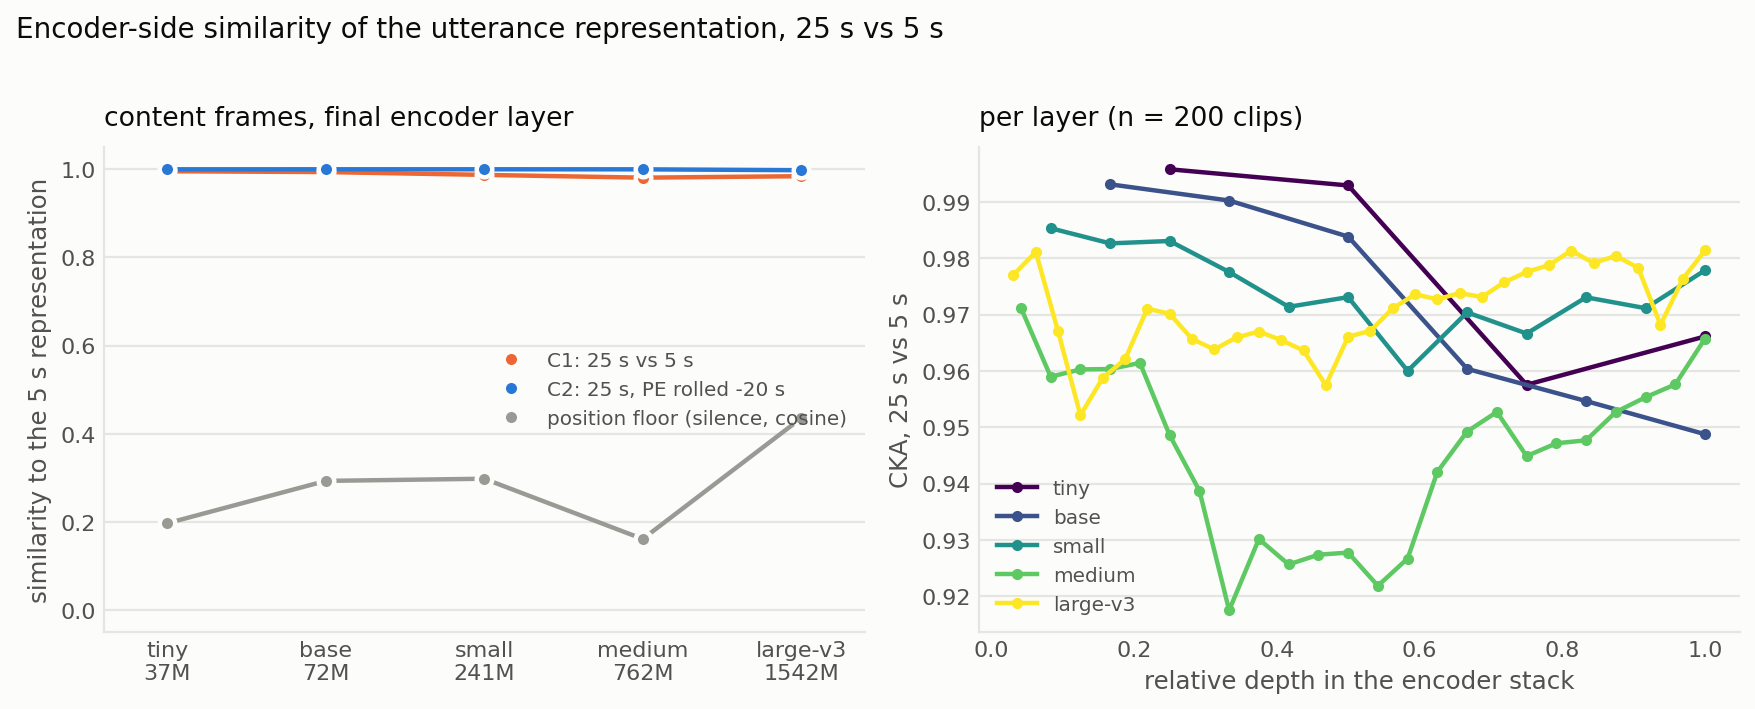

encoder_similarity.pdf is vector, Type 42 fonts, 20 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e5e2"
C_C1, C_C2, C_SIL = "#eb6834", "#2a78d6", "#9a9a95"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.0, 4.3), dpi=160)
fig.patch.set_facecolor(SURFACE)
x = np.arange(len(MODELS_DONE))

for ax in (axA, axB):
    ax.set_facecolor(SURFACE)
    ax.grid(True, axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=10, length=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRID); ax.spines[sp].set_linewidth(1)

for key, colour, lab in (("cka_c1", C_C1, "C1: 25 s vs 5 s"),
                         ("cka_c2", C_C2, "C2: 25 s, PE rolled -20 s"),
                         ("cos_sil_pos", C_SIL, "position floor (silence, cosine)")):
    y = [SIM[m][key] for m in MODELS_DONE]
    axA.plot(x, y, color=colour, linewidth=2, zorder=2)
    axA.plot(x, y, "o", color=colour, markersize=7, markeredgecolor=SURFACE,
             markeredgewidth=2, zorder=3, label=lab)
axA.set_xticks(x)
axA.set_xticklabels([f"{m}\n{SIM[m]['params_M']:.0f}M" for m in MODELS_DONE])
axA.set_xlim(-0.4, len(MODELS_DONE) - 0.6)
axA.set_ylim(-0.05, 1.05)
axA.set_ylabel("similarity to the 5 s representation", fontsize=11, color=INK2)
axA.set_title("content frames, final encoder layer", fontsize=12, color=INK, pad=10, loc="left")
leg = axA.legend(frameon=False, fontsize=9, loc="center right")
for t in leg.get_texts():
    t.set_color(INK2)

cmap = plt.get_cmap("viridis")
for i, m in enumerate(MODELS_DONE):
    pr = [r for r in layer_rows if r["model"] == m]
    axB.plot([r["depth_frac"] for r in pr], [r["cka_c1"] for r in pr],
             color=cmap(i / max(1, len(MODELS_DONE) - 1)), linewidth=2, marker="o",
             markersize=4, label=m)
axB.set_xlabel("relative depth in the encoder stack", fontsize=11, color=INK2)
axB.set_ylabel("CKA, 25 s vs 5 s", fontsize=11, color=INK2)
axB.set_title(f"per layer (n = {LAYER_CLIPS} clips)", fontsize=12, color=INK, pad=10, loc="left")
leg = axB.legend(frameon=False, fontsize=9, loc="best")
for t in leg.get_texts():
    t.set_color(INK2)

fig.suptitle("Encoder-side similarity of the utterance representation, 25 s vs 5 s",
             fontsize=12.5, color=INK, x=0.007, ha="left", y=1.02)
fig.tight_layout()

STEM = "encoder_similarity"
for ext in ("png", "pdf"):
    fig.savefig(f"{STEM}.{ext}", bbox_inches="tight", facecolor=SURFACE)          # runtime
    fig.savefig(os.path.join(DRIVE_ROOT, f"{STEM}.{ext}"),                        # Drive
                bbox_inches="tight", facecolor=SURFACE)
print(f"wrote {STEM}.png and {STEM}.pdf (+ copies on Drive)")
plt.show()

_pdf = open(f"{STEM}.pdf", "rb").read()
assert b"/Subtype /Image" not in _pdf and b"/DCTDecode" not in _pdf, "PDF contains a raster layer"
assert b"/Type3" not in _pdf, "PDF embeds Type 3 fonts; pdf.fonttype did not take effect"
print(f"{STEM}.pdf is vector, Type 42 fonts, {len(_pdf) / 1024:.0f} KB")

try:
    from google.colab import files
    files.download(f"{STEM}.pdf")
except Exception as exc:
    print(f"local download unavailable ({type(exc).__name__}); "
          f"{STEM}.pdf is on Drive at {DRIVE_ROOT}")

## 11. Write provenance and verify

The results file is numbers and identifiers by construction — this notebook never reads a
transcript — but the guard is asserted anyway, because saving a Colab notebook back to GitHub
commits its outputs and a licence violation in git history is not fixable by a later commit.

Reading the file back from Drive proves the write reached Drive rather than sitting in a FUSE
buffer.

In [13]:
FORBIDDEN = {"text", "reference", "hypothesis", "ref", "hyp", "transcript"}
IDENT = {"model", "path", "speaker", "region"}
assert not (set(FIELDS) & FORBIDDEN), "a forbidden column is present"


def _numericish(v):
    if v == "":
        return True
    try:
        float(v); return True
    except ValueError:
        return False


leaks = [(k, r[k]) for r in rows for k in FIELDS if k not in IDENT and not _numericish(r[k])]
assert not leaks, f"non-numeric values in git-safe columns: {leaks[:5]}"


def _jsonable(v):
    if isinstance(v, (np.floating, np.integer)):
        return v.item()
    if isinstance(v, dict):
        return {str(k): _jsonable(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)):
        return [_jsonable(x) for x in v]
    return v


PROVENANCE["checkpoints"] = ckpt
PROVENANCE["results"] = {
    "n_rows": len(rows), "models": MODELS_DONE,
    "safe_csv": SAFE_CSV, "safe_csv_sha256": sha256_file(SAFE_CSV),
    "layer_csv": LAYER_CSV, "layer_csv_sha256": sha256_file(LAYER_CSV),
    "layer_clips": LAYER_CLIPS,
    "similarity": _jsonable(SIM), "verdict": _jsonable(VERDICT),
}
with open(PROV_JSON, "w") as f:
    json.dump(_jsonable(PROVENANCE), f, indent=1)
print(f"wrote provenance -> {PROV_JSON}")

back = list(csv.DictReader(open(SAFE_CSV, newline="")))
assert len(back) == len(rows)
assert all(b["path"] == r["path"] and b["cka_c1"] == r["cka_c1"] for b, r in zip(back, rows))
assert not (set(back[0]) & FORBIDDEN)
print(f"verified: {len(back)} rows read back from Drive, no text-bearing column")

wrote provenance -> /content/drive/MyDrive/NAACL/encsim_provenance.json
verified: 5000 rows read back from Drive, no text-bearing column


## 12. Standalone reload

No GPU, no TIMIT, no earlier cell. Everything the verdict rests on is recoverable from the git-safe
file alone.

In [1]:
import csv, collections, numpy as np

SAFE = "/content/drive/MyDrive/NAACL/encsim_per_utterance.csv"   # or a local download
rr = list(csv.DictReader(open(SAFE, newline="")))
GG = collections.defaultdict(list)
for r in rr:
    GG[r["model"]].append(r)
ms = sorted(GG, key=lambda m: ["tiny", "base", "small", "medium", "large-v3"].index(m))

print(f"reloaded {len(rr)} rows | {len(ms)} models | {len(GG[ms[0]])} clips each\n")
print(f"{'model':>9s} | {'cka C1':>7s} {'cka C2':>7s} {'cos C1':>7s} {'cos sil':>7s} "
      f"{'damage':>8s}")
print("-" * 60)
for m in ms:
    g = lambda k: float(np.mean([float(r[k]) for r in GG[m]]))
    print(f"{m:>9s} | {g('cka_c1'):7.4f} {g('cka_c2'):7.4f} {g('cos_c1'):7.4f} "
          f"{g('cos_sil'):7.4f} {1-g('cka_c1'):8.4f}")

print("\ncos C1 well below cka C1, with cos sil near zero, means the cosine gap is position "
      "rather than\ndamage: identical silent input scores just as far apart.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NAACL/encsim_per_utterance.csv'